# Notebook 14: Orchestrator Agent (Multi-Agent Routing)

## Learning Objectives
- Build a LangGraph pipeline with **conditional edges** (non-linear routing)
- Use **tool-based intent classification** to route queries to sub-agents
- Integrate **three delegates**: Designer (NB 11), Analytics (NB 12), and Education (NB 13)
- Support **multi-turn conversation** with automatic intent routing per message

## Architecture
```
         classify_intent
              |
    +---------+---------+
    |         |         |
designer  analytics  education
_delegate _delegate  _delegate
    |         |         |
    +---------+---------+
              |
       format_response -> END
```

## How It Works
1. **classify_intent**: The LLM is given three handoff tools and must call one to signal routing
2. **designer_delegate**: Runs the NB11 portfolio profiling agent (tool-calling loop with MemorySaver)
3. **analytics_delegate**: Runs the full NB12 pipeline (live data, 17-rule scoring, LLM analysis)
4. **education_delegate**: Runs the NB13 pipeline (context enrichment, multi-turn chat)
5. **format_response**: Convergence node -- all delegates merge back before END

| Feature | NB 11 (Designer) | NB 12 (Analytics) | NB 13 (Education) | NB 14 (This) |
|---------|-----------------|---------------------|--------------------|---------------|
| Graph shape | Agent loop | Linear (5 nodes) | Linear (2 nodes) | Conditional routing |
| Routing | Tool loop | None | None | Tool-based LLM classification |
| Sub-agents | N/A | N/A | N/A | Designer + Analytics + Education |
| Conditional edges | Yes | No | No | Yes (`add_conditional_edges`) |
| Conversation | Multi-turn profiling | One-shot | Multi-turn | Multi-turn with routing |

## Four-Agent System
| Notebook | Role | Input | Output |
|----------|------|-------|--------|
| **11** (Designer) | Conversational profiling chatbot | User conversation | `portfolio.json` |
| **12** (Analytics) | Full scoring & risk | `portfolio.json` | Analysis report |
| **13** (Education) | Interactive chat | `portfolio.json` | Conversational advice |
| **14** (Orchestrator) | Route to sub-agents | User queries | Delegated responses |

## How to Use This Notebook

### Prerequisites
1. **Notebook 11 is optional**: If `../data/outputs/portfolio.json` exists, it will be used. Otherwise, a sample portfolio is loaded automatically.
2. **Environment file**: Create a `.env` file in the project root (`../.env`) with your API keys:
   ```
   LLM_PROVIDER=openai
   LLM_MODEL=gpt-4.1-mini
   OPENAI_API_KEY=your-openai-key
   SERPER_API_KEY=your-serper-key
   ```
3. **Install packages**: The first code cell installs all required packages automatically.

### Running the Notebook
1. **Run All Cells** (recommended): Use `Kernel > Restart & Run All` or click **Run All**. The notebook will:
   - Install dependencies and load the portfolio (or use the sample)
   - Build the 3-branch orchestrator graph
   - Run demo queries for each agent type (Designer, Analytics, Education)
   - Run 17 demo queries showcasing cross-agent routing
2. **Run Cell by Cell**: Execute with `Shift + Enter` to observe routing decisions.

### Demo Queries
The notebook routes each query to the appropriate agent automatically:

| Demo | Query | Routes To |
|------|-------|-----------|
| 1 | "How is my portfolio doing this month?" | Analytics |
| 2 | "Actually, before that -- explain what Sharpe ratio means." | Education |
| 3 | "Now, based on that explanation, should I rebalance?" | Analytics |
| 4 | "Only analyze my healthcare ETFs." | Analytics |
| 5 | "How is VTI performing compared to my total portfolio?" | Analytics |
| 6 | "Which holding contributes most to my volatility?" | Analytics |
| 7 | "What happens if I remove NVDA?" | Analytics |
| 8 | "What if I increase bonds to 30%?" | Designer |
| 9 | "What happens if interest rates rise?" | Education |
| 10 | "Simulate a recession scenario." | Analytics |
| 11 | "How would my portfolio behave in a 2008-type crash?" | Analytics |
| 12 | "I want to retire at 60. Am I on track?" | Designer |
| 13 | "Can I reduce risk but maintain returns?" | Analytics |
| 14 | "How much healthcare exposure is too much?" | Education |
| 15 | "Explain beta in the context of my portfolio." | Education |
| 16 | "Why is my portfolio more volatile than the S&P?" | Analytics |
| 17 | "Teach me how diversification reduces risk using my holdings." | Education |

### Interactive Mode
After the demos, there is an **Interactive Chat** cell for free-form conversation. The orchestrator re-classifies intent on every turn, so you can freely switch between designing, analyzing, and learning.

## Installation

In [1]:
%pip install langchain langchain-openai langchain-community langgraph python-dotenv pandas pydantic yfinance google-search-results --quiet

print("Packages installed")


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Packages installed


## Imports

In [2]:
import json
import os
from typing import Annotated, Literal, Sequence

import pandas as pd
import numpy as np
import yfinance as yf
from dotenv import load_dotenv
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, StateGraph, MessagesState
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from pydantic import BaseModel, Field
from IPython.display import Image, display, Markdown

from ai_course_utils import load_llm_from_env, display_config

# Load environment
load_dotenv()
load_dotenv('../.env')

print("Imports successful")

Imports successful


## Configuration

In [3]:
display_config()

API CONFIGURATION (.env file)
LLM Provider:    openai
LLM Model:       gpt-4.1-mini
Temperature:     0.0

API Keys Status:
  OpenAI               Set
  Google               Not set
  Mistral              Not set
  Anthropic            Not set
  Serper (Web Search)  Set

Data Files:
  Provide file paths as function parameters
  Example: load_use_case_config('your_file.xlsx')


## Load Portfolio

If a portfolio JSON exists from Notebook 11, the orchestrator will use it.
If not, a **sample portfolio** is loaded automatically so the Analytics
and Education delegates work out of the box. The Designer delegate can
create a new portfolio at any time, replacing the sample.

In [4]:
# ============================================================================
# USER INPUT: Path to portfolio JSON from Notebook 11
# ============================================================================
portfolio_file = "../data/outputs/portfolio.json"

# Sample portfolio used when Notebook 11 has not been run yet
SAMPLE_PORTFOLIO = {
    "name": "Sample Balanced Growth Portfolio",
    "description": "A diversified portfolio for demonstration purposes, "
                   "blending broad market ETFs with sector exposure and bonds.",
    "holdings": [
        {"ticker": "VTI",  "company_name": "Vanguard Total Stock Market ETF",
         "allocation_pct": 25.0, "investment_type": "ETF",
         "rationale": "Broad US equity exposure"},
        {"ticker": "QQQ",  "company_name": "Invesco QQQ Trust",
         "allocation_pct": 15.0, "investment_type": "ETF",
         "rationale": "Growth-oriented tech exposure"},
        {"ticker": "XLV",  "company_name": "Health Care Select Sector SPDR Fund",
         "allocation_pct": 10.0, "investment_type": "ETF",
         "rationale": "Healthcare sector tilt"},
        {"ticker": "VWO",  "company_name": "Vanguard FTSE Emerging Markets ETF",
         "allocation_pct": 10.0, "investment_type": "ETF",
         "rationale": "Emerging market diversification"},
        {"ticker": "XLE",  "company_name": "Energy Select Sector SPDR Fund",
         "allocation_pct": 5.0,  "investment_type": "ETF",
         "rationale": "Energy sector and inflation hedge"},
        {"ticker": "AAPL", "company_name": "Apple Inc.",
         "allocation_pct": 10.0, "investment_type": "Stock",
         "rationale": "Large-cap growth with strong cash flow"},
        {"ticker": "JNJ",  "company_name": "Johnson & Johnson",
         "allocation_pct": 5.0,  "investment_type": "Stock",
         "rationale": "Defensive healthcare with dividend income"},
        {"ticker": "BND",  "company_name": "Vanguard Total Bond Market ETF",
         "allocation_pct": 15.0, "investment_type": "Bond ETF",
         "rationale": "Fixed income for stability and income"},
        {"ticker": "GLD",  "company_name": "SPDR Gold Shares",
         "allocation_pct": 5.0,  "investment_type": "Commodity ETF",
         "rationale": "Inflation hedge and portfolio diversifier"},
    ],
}

if os.path.exists(portfolio_file):
    with open(portfolio_file) as f:
        PORTFOLIO = json.load(f)
    print(f"Portfolio loaded from {portfolio_file}")
else:
    PORTFOLIO = SAMPLE_PORTFOLIO
    print(f"No portfolio file found at {portfolio_file}")
    print("Using SAMPLE portfolio for demonstration\n")

print(f"  Name: {PORTFOLIO['name']}")
print(f"  Holdings: {len(PORTFOLIO['holdings'])}")
print()
for h in PORTFOLIO['holdings']:
    print(f"  {h['ticker']:<6} {h['allocation_pct']:>5.1f}%  {h['company_name']}")

No portfolio file found at ../data/outputs/portfolio.json
Using SAMPLE portfolio for demonstration

  Name: Sample Balanced Growth Portfolio
  Holdings: 9

  VTI     25.0%  Vanguard Total Stock Market ETF
  QQQ     15.0%  Invesco QQQ Trust
  XLV     10.0%  Health Care Select Sector SPDR Fund
  VWO     10.0%  Vanguard FTSE Emerging Markets ETF
  XLE      5.0%  Energy Select Sector SPDR Fund
  AAPL    10.0%  Apple Inc.
  JNJ      5.0%  Johnson & Johnson
  BND     15.0%  Vanguard Total Bond Market ETF
  GLD      5.0%  SPDR Gold Shares


## S&P 500 Sector Benchmark

Used by the analytics delegate for sector weight comparison.

In [5]:
SP500_SECTOR_WEIGHTS = {
    "Technology": 31.0,
    "Healthcare": 12.0,
    "Financial Services": 13.0,
    "Consumer Cyclical": 10.0,
    "Communication Services": 9.0,
    "Industrials": 8.0,
    "Consumer Defensive": 6.0,
    "Energy": 4.0,
    "Utilities": 3.0,
    "Real Estate": 2.0,
    "Basic Materials": 2.0,
}

print("S&P 500 sector benchmark loaded")

S&P 500 sector benchmark loaded


## Define Orchestrator State

A unified state that carries fields for both sub-agents plus
orchestrator-specific routing fields (`intent`, `route_message`).

In [6]:
class OrchestratorState(BaseModel):
    """State that flows through the orchestrator graph.

    Combines fields needed by:
    - Orchestrator routing (intent, route_message)
    - Analytics delegate (portfolio, benchmark_context, holdings_analysis, risk_metrics)
    - Education delegate (system_prompt, portfolio_context)
    - Shared (messages)
    """

    model_config = {"arbitrary_types_allowed": True}

    # Shared
    messages: Annotated[Sequence[BaseMessage], add_messages] = []

    # Routing
    intent: str = ""
    route_message: str = ""

    # Analytics delegate fields
    portfolio: dict = {}
    benchmark_context: str = ""
    sector_rows: list[dict] = []
    holdings_analysis: list[dict] = []
    risk_metrics: dict = {}

    # Education delegate fields
    system_prompt: str = ""
    portfolio_context: str = ""


print("OrchestratorState defined")
print("  Routing fields: intent, route_message")
print("  Analytics fields: portfolio, benchmark_context, holdings_analysis, risk_metrics")
print("  Education fields: system_prompt, portfolio_context")

OrchestratorState defined
  Routing fields: intent, route_message
  Analytics fields: portfolio, benchmark_context, holdings_analysis, risk_metrics
  Education fields: system_prompt, portfolio_context


## Define Handoff Tools

These are routing signals — the LLM calls one of these tools to indicate
which sub-agent should handle the query. The tools are never actually
executed; only the tool call name is inspected for routing.

In [7]:
@tool
def transfer_to_designer(reason: str) -> str:
    """Transfer to the Portfolio Designer Agent.

    Use this when the user wants to:
    - Create, build, or design a new investment portfolio
    - Get profiled for investment goals, risk tolerance, timeline
    - Modify or redesign their existing portfolio
    - Discuss what allocation or ETF mix to use
    """
    return reason


@tool
def transfer_to_analytics(reason: str) -> str:
    """Transfer to the Portfolio Analytics Agent.

    Use this when the user asks about:
    - Portfolio analysis, scoring, or risk assessment
    - Market data, technical indicators (RSI, MACD, SMA)
    - Sector weights, benchmark comparison
    - Rebalancing recommendations
    - Holdings performance or signals (BUY/HOLD/SELL)
    """
    return reason


@tool
def transfer_to_education(reason: str) -> str:
    """Transfer to the Investment Education Agent.

    Use this when the user asks about:
    - Investment concepts or terminology
    - How financial metrics work (P/E, beta, etc.)
    - General investment strategies or advice
    - Learning about portfolio management
    - Explanations of analysis results
    - Follow-up questions about previous topics
    """
    return reason


handoff_tools = [transfer_to_designer, transfer_to_analytics, transfer_to_education]

print("Handoff tools defined")
print("  - transfer_to_designer")
print("  - transfer_to_analytics")
print("  - transfer_to_education")

Handoff tools defined
  - transfer_to_designer
  - transfer_to_analytics
  - transfer_to_education


## Classification Prompt

In [8]:
CLASSIFIER_PROMPT = """You are an orchestrator agent that routes user queries to the \
correct specialist agent.

You have access to three agents:
1. **Designer Agent**: For creating, building, or redesigning investment portfolios. \
This includes investor profiling conversations (risk tolerance, goals, timeline) \
and portfolio construction requests.
2. **Analytics Agent**: For portfolio analysis, market data, risk assessment, \
scoring, and rebalancing recommendations. Requires a portfolio to be loaded.
3. **Education Agent**: For learning about investment concepts, explanations, \
general questions, and follow-up discussions.

Rules:
- If the user wants to CREATE, BUILD, or DESIGN a portfolio, use transfer_to_designer.
- If the user asks for analysis, scores, risk, or data about their existing portfolio, \
use transfer_to_analytics.
- If the user asks to learn, understand, or explain something, use \
transfer_to_education.
- If the query is ambiguous between analytics and education, prefer \
transfer_to_education.
- You MUST call exactly one tool. Do not respond directly."""

print("Classifier prompt defined")

Classifier prompt defined


## Analytics Helper Functions (from Notebook 12)

Market data fetching, technical indicators, 17-rule scoring,
and portfolio risk computation.

In [9]:
def _scalar(x):
    """Convert numpy/pandas scalar to plain Python float."""
    try:
        if hasattr(x, "item"):
            return x.item()
        if pd.isna(x):
            return None
        return float(x)
    except (TypeError, ValueError):
        return None


def fetch_price_history(ticker: str, period: str = "1y") -> pd.DataFrame:
    """Fetch OHLCV history from yfinance."""
    try:
        df = yf.download(ticker, period=period, progress=False, auto_adjust=True)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        return df
    except Exception as e:
        print(f"    yfinance download failed for {ticker}: {e}")
        return pd.DataFrame()


def fetch_fundamentals(ticker: str) -> dict:
    """Fetch fundamental metrics from yfinance."""
    try:
        info = yf.Ticker(ticker).info
        return {
            "company_name": info.get("shortName") or info.get("longName", ticker),
            "sector": info.get("sector", "Unknown"),
            "current_price": info.get("currentPrice") or info.get("regularMarketPrice"),
            "pe_ratio": info.get("trailingPE") or info.get("forwardPE"),
            "pb_ratio": info.get("priceToBook"),
            "roe": info.get("returnOnEquity"),
            "dividend_yield": info.get("dividendYield"),
            "beta": info.get("beta"),
            "market_cap": info.get("marketCap"),
            "52_week_high": info.get("fiftyTwoWeekHigh"),
            "52_week_low": info.get("fiftyTwoWeekLow"),
            "profit_margins": info.get("profitMargins"),
            "revenue_growth": info.get("revenueGrowth"),
            "debt_to_equity": info.get("debtToEquity"),
        }
    except Exception as e:
        print(f"    yfinance info failed for {ticker}: {e}")
        return {"company_name": ticker, "sector": "Unknown"}


def compute_technical_indicators(df: pd.DataFrame) -> dict | None:
    """Compute RSI, MACD, SMA from price history."""
    if df.empty or len(df) < 50:
        return None

    close = df["Close"]

    # SMAs
    sma_50 = close.rolling(50).mean()
    sma_200 = close.rolling(200).mean() if len(df) >= 200 else pd.Series(dtype=float)

    # MACD (12/26/9)
    ema_12 = close.ewm(span=12, adjust=False).mean()
    ema_26 = close.ewm(span=26, adjust=False).mean()
    macd_line = ema_12 - ema_26
    signal_line = macd_line.ewm(span=9, adjust=False).mean()

    # RSI (14-period)
    delta = close.diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))

    latest = df.iloc[-1]

    return {
        "current_price": _scalar(latest["Close"]),
        "sma_50": _scalar(sma_50.iloc[-1]),
        "sma_200": _scalar(sma_200.iloc[-1]) if not sma_200.empty else None,
        "macd": _scalar(macd_line.iloc[-1]),
        "signal_line": _scalar(signal_line.iloc[-1]),
        "rsi": _scalar(rsi.iloc[-1]),
        "high_52w": _scalar(df["High"].max()) if "High" in df.columns else None,
        "low_52w": _scalar(df["Low"].min()) if "Low" in df.columns else None,
    }


print("Market data functions defined")
print("  - _scalar, fetch_price_history, fetch_fundamentals")
print("  - compute_technical_indicators")

Market data functions defined
  - _scalar, fetch_price_history, fetch_fundamentals
  - compute_technical_indicators


## Rule-Based Scoring (17 Rules)

Each rule adds or subtracts points; the total determines BUY/HOLD/SELL.

In [10]:
def compute_rule_scores(technicals: dict, fundamentals: dict) -> dict:
    """Compute rule-based scores from technical + fundamental data.

    17 individual rules, each adding or subtracting points.
    """
    price = technicals.get("current_price")
    sma50 = technicals.get("sma_50")
    sma200 = technicals.get("sma_200")
    macd = technicals.get("macd")
    signal = technicals.get("signal_line")
    rsi = technicals.get("rsi")
    high52 = technicals.get("high_52w")
    low52 = technicals.get("low_52w")

    pe = fundamentals.get("pe_ratio")
    pb = fundamentals.get("pb_ratio")
    roe = fundamentals.get("roe")
    dy = fundamentals.get("dividend_yield")

    scores = {}

    scores["macd_signal"] = 2 if (macd is not None and signal is not None and macd > signal) else 0
    scores["rsi_bullish"] = 2 if (rsi is not None and 60 < rsi < 70) else 0
    scores["rsi_bearish"] = -2 if (rsi is not None and rsi < 40) else 0
    scores["sma_bull"] = 3 if (sma50 and sma200 and sma50 > sma200) else 0
    scores["sma_bear"] = -3 if (sma50 and sma200 and sma50 < sma200) else 0
    scores["rsi_overbought"] = -2 if (rsi and rsi > 70) else 0
    scores["rsi_neutral_bull"] = 1 if (rsi and 45 < rsi < 60) else 0
    scores["pe_value"] = 2 if (pe and pe < 25) else 0
    scores["pe_high"] = -2 if (pe and pe > 40) else 0
    scores["pb_value"] = 1 if (pb and pb < 3) else 0
    scores["pb_high"] = -1 if (pb and pb > 10) else 0
    scores["roe_strong"] = 2 if (roe and roe > 0.15) else 0
    scores["roe_weak"] = -1 if (roe and roe < 0.05) else 0
    scores["dividend"] = 1 if (dy and dy > 0.01) else 0
    scores["near_high"] = -1 if (price and high52 and price >= high52 * 0.90) else 0
    scores["near_low"] = 1 if (price and low52 and price <= low52 * 1.10) else 0

    scores["total_score"] = sum(scores.values())
    return scores


def rule_recommendation(total_score: int) -> str:
    """Map total score to BUY/HOLD/SELL."""
    if total_score >= 9:
        return "BUY"
    elif total_score >= 0:
        return "HOLD"
    else:
        return "SELL"


def combine_signals(rule_signal: str, llm_signal: str) -> tuple[str, float]:
    """Combine rule-based and LLM signals (60% rules / 40% LLM)."""
    mapping = {"BUY": 1, "HOLD": 0, "SELL": -1}
    score = 0.6 * mapping.get(rule_signal.upper(), 0) + 0.4 * mapping.get(llm_signal.upper(), 0)

    if score >= 0.5:
        return "KEEP / INCREASE", score
    elif score <= -0.5:
        return "REDUCE / SELL", score
    return "MAINTAIN / WATCH", score


print("Scoring functions defined")
print("  - compute_rule_scores (17 rules)")
print("  - rule_recommendation")
print("  - combine_signals (60/40 rule/LLM weighting)")

Scoring functions defined
  - compute_rule_scores (17 rules)
  - rule_recommendation
  - combine_signals (60/40 rule/LLM weighting)


## Full Holding Analysis

Combines price history, fundamentals, technicals, and rule-based scoring
into a single analysis dict per holding.

In [11]:
def analyze_holding(ticker: str, allocation_pct: float) -> dict:
    """Run complete analysis for a single holding."""
    ticker = ticker.upper().strip()

    fundamentals = fetch_fundamentals(ticker)
    price_df = fetch_price_history(ticker)
    technicals = compute_technical_indicators(price_df)

    if technicals is None:
        return {
            "ticker": ticker,
            "allocation_pct": allocation_pct,
            "data_available": False,
            "company_name": fundamentals.get("company_name", ticker),
            "sector": fundamentals.get("sector", "Unknown"),
        }

    scores = compute_rule_scores(technicals, fundamentals)
    rule_signal = rule_recommendation(scores["total_score"])

    return {
        "ticker": ticker,
        "allocation_pct": allocation_pct,
        "data_available": True,
        "company_name": fundamentals.get("company_name", ticker),
        "sector": fundamentals.get("sector", "Unknown"),
        "current_price": technicals.get("current_price"),
        "sma_50": technicals.get("sma_50"),
        "sma_200": technicals.get("sma_200"),
        "macd": technicals.get("macd"),
        "signal_line": technicals.get("signal_line"),
        "rsi": technicals.get("rsi"),
        "high_52w": technicals.get("high_52w"),
        "low_52w": technicals.get("low_52w"),
        "pe_ratio": fundamentals.get("pe_ratio"),
        "pb_ratio": fundamentals.get("pb_ratio"),
        "roe": fundamentals.get("roe"),
        "dividend_yield": fundamentals.get("dividend_yield"),
        "beta": fundamentals.get("beta"),
        "profit_margins": fundamentals.get("profit_margins"),
        "revenue_growth": fundamentals.get("revenue_growth"),
        "debt_to_equity": fundamentals.get("debt_to_equity"),
        "rule_scores": scores,
        "total_score": scores["total_score"],
        "rule_signal": rule_signal,
    }


print("analyze_holding defined")

analyze_holding defined


## Portfolio-Level Risk Metrics

In [12]:
def compute_portfolio_risk(holdings_analysis: list[dict]) -> dict:
    """Compute portfolio-level risk metrics from per-holding analysis."""
    available = [h for h in holdings_analysis if h.get("data_available")]
    if not available:
        return {"overall_risk_level": "UNKNOWN", "detail": "No market data available."}

    # Weighted average beta
    betas = [(h["beta"], h["allocation_pct"]) for h in available if h.get("beta") is not None]
    avg_beta = (
        sum(b * w for b, w in betas) / sum(w for _, w in betas)
        if betas else None
    )

    # Weighted average P/E
    pes = [(h["pe_ratio"], h["allocation_pct"]) for h in available if h.get("pe_ratio") is not None]
    avg_pe = (
        sum(p * w for p, w in pes) / sum(w for _, w in pes)
        if pes else None
    )

    # Concentration: HHI
    weights = [h["allocation_pct"] for h in available]
    hhi = sum((w / 100) ** 2 for w in weights) if weights else 0
    max_weight = max(weights) if weights else 0

    # Sector breakdown
    sector_weights: dict[str, float] = {}
    for h in available:
        s = h.get("sector", "Unknown")
        sector_weights[s] = sector_weights.get(s, 0) + h["allocation_pct"]

    # High-risk holdings
    high_risk = [h for h in available if h.get("rule_signal") == "SELL"]

    # Overall risk assessment
    risk_factors = 0
    if avg_beta is not None and avg_beta > 1.3:
        risk_factors += 1
    if max_weight > 25:
        risk_factors += 1
    if len(high_risk) > len(available) * 0.3:
        risk_factors += 1
    if hhi > 0.15:
        risk_factors += 1

    risk_level = "HIGH" if risk_factors >= 3 else "MODERATE" if risk_factors >= 1 else "LOW"

    return {
        "overall_risk_level": risk_level,
        "weighted_avg_beta": round(avg_beta, 3) if avg_beta else None,
        "weighted_avg_pe": round(avg_pe, 2) if avg_pe else None,
        "concentration_hhi": round(hhi, 4),
        "max_single_holding_pct": round(max_weight, 1),
        "sector_breakdown": {k: round(v, 1) for k, v in sorted(sector_weights.items(), key=lambda x: -x[1])},
        "high_risk_holdings": [h["ticker"] for h in high_risk],
        "holdings_with_data": len(available),
        "holdings_without_data": len(holdings_analysis) - len(available),
    }


print("compute_portfolio_risk defined")

compute_portfolio_risk defined


## Structured LLM Signals

Uses `with_structured_output` to get typed BUY/HOLD/SELL recommendations
from the LLM, then combines them with rule-based scores (60/40 weighting).

In [13]:
class HoldingSignal(BaseModel):
    """LLM recommendation for a single holding."""
    ticker: str = Field(description="Stock ticker symbol")
    signal: str = Field(description="BUY, HOLD, or SELL")


class HoldingSignals(BaseModel):
    """Structured LLM output: per-holding BUY/HOLD/SELL signals."""
    signals: list[HoldingSignal]


def get_llm_signals(holdings_summary: list[dict], llm) -> list[dict] | None:
    """Ask the LLM for per-holding BUY/HOLD/SELL signals.

    Uses with_structured_output for typed Pydantic responses.
    Combines LLM signal with rule signal using 60/40 weighting.
    """
    tickers_with_data = [
        h for h in holdings_summary
        if h.get("data_available", True) and h.get("rule_signal")
    ]
    if not tickers_with_data:
        return None

    prompt = (
        "For each stock below, give a BUY, HOLD, or SELL recommendation "
        "based on the technical and fundamental data provided.\n\n"
        + json.dumps(tickers_with_data, indent=2, default=str)
    )

    try:
        structured_llm = llm.with_structured_output(HoldingSignals)
        result = structured_llm.invoke([HumanMessage(content=prompt)])

        signal_map = {s.ticker.upper(): s.signal.upper() for s in result.signals}

        for h in holdings_summary:
            ticker = h["ticker"].upper()
            if ticker in signal_map and h.get("rule_signal"):
                h["llm_signal"] = signal_map[ticker]
                combined_rec, combined_score = combine_signals(
                    h["rule_signal"], signal_map[ticker]
                )
                h["combined_signal"] = combined_rec
                h["combined_score"] = round(combined_score, 3)

        return holdings_summary
    except Exception as e:
        print(f"    Failed to get LLM signals: {e}")
        return None


print("Structured LLM signals defined")
print("  - HoldingSignal, HoldingSignals (Pydantic models)")
print("  - get_llm_signals (with_structured_output + combine_signals)")

Structured LLM signals defined
  - HoldingSignal, HoldingSignals (Pydantic models)
  - get_llm_signals (with_structured_output + combine_signals)


## Analytics Analysis Prompt

In [14]:
ANALYSIS_PROMPT = """You are an expert investment analyst evaluating a portfolio. \
You have been provided with:

1. **Sector weight comparison** against the S&P 500 benchmark
2. **Per-holding analysis** with live technical indicators (RSI, MACD, SMA), \
fundamentals (P/E, P/B, ROE, beta), and rule-based BUY/HOLD/SELL scores
3. **Portfolio-level risk metrics** (beta, concentration, sector breakdown)

Produce a comprehensive analysis covering ALL of the following:

## Sector Exposure
- Which sectors are overweight/underweight vs S&P 500
- Concentration risks in specific sectors

## Individual Holdings Review
- Flag holdings with SELL signals or very low scores
- Highlight strong BUY-signal holdings
- Note any overbought (RSI >70) or oversold (RSI <30) positions

## Risk Assessment
- Portfolio beta and volatility exposure
- Concentration risk (single-stock and sector)
- Valuation risk (average P/E vs market)

## ROI & Performance Indicators
- Holdings with strong momentum (MACD bullish, RSI 50-70)
- Dividend income potential
- Growth vs value tilt

## Rebalancing Recommendations
- Specific positions to reduce or increase
- Sector adjustments needed to improve diversification
- Priority actions ranked by urgency

Format in markdown with clear sections. Be specific \u2014 use ticker symbols, \
percentages, and scores from the data provided. Keep each section concise."""

print("Analysis prompt defined")

Analysis prompt defined


## Education System Prompt & Sector Comparison

In [15]:
EDUCATION_PROMPT = """You are an expert investment education assistant. \
Your role is to help users understand investment concepts, portfolio \
management, and financial markets.

Guidelines:
- Explain concepts clearly using plain language
- Use real-world examples when possible
- If the user has a portfolio, reference their specific holdings to \
make explanations more relevant and personalised
- Cover topics like: asset allocation, diversification, risk management, \
technical analysis (RSI, MACD, SMA), fundamental analysis (P/E, P/B, ROE), \
sector rotation, rebalancing, dividend investing, growth vs value
- Always remind users that this is for educational purposes only and \
not financial advice
- When discussing the user's portfolio, explain the \"why\" behind \
observations (e.g. why being overweight in tech increases volatility)
- Be conversational and encourage follow-up questions"""


def compute_sector_comparison(holdings: list[dict]) -> str:
    """Compare portfolio sector weights against S&P 500."""
    if not holdings:
        return ""

    sector_weights = {}
    for h in holdings:
        try:
            info = yf.Ticker(h["ticker"]).info
            sector = info.get("sector", "Unknown")
        except Exception:
            sector = "Unknown"
        sector_weights[sector] = sector_weights.get(sector, 0) + h.get("allocation_pct", 0)

    lines = ["Sector Allocation Comparison (Portfolio vs S&P 500):"]
    all_sectors = sorted(set(list(SP500_SECTOR_WEIGHTS.keys()) + list(sector_weights.keys())))

    for sector in all_sectors:
        port_w = sector_weights.get(sector, 0)
        sp_w = SP500_SECTOR_WEIGHTS.get(sector, 0)
        diff = port_w - sp_w
        if port_w > 0 or abs(diff) > 3:
            status = "OVERWEIGHT" if diff > 5 else "UNDERWEIGHT" if diff < -5 else "NEUTRAL"
            lines.append(
                f"  {sector}: Portfolio {port_w:.1f}% vs S&P 500 {sp_w:.1f}% "
                f"({diff:+.1f}%) [{status}]"
            )

    lines.append("\nOverweight = more than S&P 500 benchmark; underweight = less.")
    return "\n".join(lines)


print("Education prompt and sector comparison defined")

Education prompt and sector comparison defined


## Designer System Prompt & Tools (from Notebook 11)

The designer delegate uses a conversational profiling agent with two
tools: web search for market context and portfolio generation for
saving structured portfolios to disk.

In [16]:
PORTFOLIO_FILE = "../data/outputs/portfolio.json"


def save_portfolio(portfolio: dict):
    """Save portfolio to JSON file for use by other agents."""
    os.makedirs(os.path.dirname(PORTFOLIO_FILE), exist_ok=True)
    with open(PORTFOLIO_FILE, "w") as f:
        json.dump(portfolio, f, indent=2)
    print(f"Portfolio saved to {PORTFOLIO_FILE}")
    print(f"  Name: {portfolio.get('name', 'Unnamed')}")
    print(f"  Holdings: {len(portfolio.get('holdings', []))}")


DESIGNER_PROMPT = """\
You are an expert investment profiling coach and portfolio designer. \
Your role is to help users build a personalised investment portfolio \
through conversation.

## Your Process
1. **Profile the investor**: Ask about their age, risk tolerance, \
investment goals (growth, income, preservation), time horizon, \
existing investments, and any sector preferences or exclusions.
2. **Gather context**: Use the search_web tool to look up current market \
conditions, ETF options, or sector performance when relevant to the \
user's needs.
3. **Design the portfolio**: Once you have a clear investor profile, \
use the portfolio_generation tool to create and save a structured \
portfolio with specific holdings, allocations, and rationales.

## Profiling Questions to Ask (adapt to context)
- What is your investment time horizon? (e.g., 5, 10, 20+ years)
- What is your risk tolerance? (conservative, moderate, aggressive)
- What are your primary goals? (growth, income, capital preservation)
- Do you prefer ETFs, individual stocks, or a mix?
- Are there sectors you want to emphasise or avoid?
- What is your approximate age and retirement timeline?

## Guidelines
- Be conversational and encouraging -- do not overwhelm with all \
questions at once. Ask 2-3 questions per turn.
- If the user provides enough information upfront (e.g., \"I am 45, \
moderate risk, retiring in 15 years\"), skip redundant questions and \
move toward portfolio design.
- When searching for market data, summarise key findings concisely.
- When generating a portfolio, include 6-12 holdings with a mix of \
asset types (stocks, ETFs, bonds) appropriate to the investor's profile.
- Allocations must sum to approximately 100%.
- After generating a portfolio, explain your reasoning for each holding \
and offer to adjust it based on feedback.
- Always remind users: this is for educational purposes only, not \
financial advice.
"""


@tool
def designer_search_web(query: str) -> str:
    """Search the web for current market data, ETF information,
    sector performance, or investment news."""
    from langchain_community.utilities import GoogleSerperAPIWrapper
    try:
        search = GoogleSerperAPIWrapper()
        return search.run(query)
    except Exception as e:
        return f"Search error: {str(e)}"


@tool
def portfolio_generation(
    portfolio_name: str,
    description: str,
    holdings: list[dict],
) -> str:
    """Generate and save a structured investment portfolio.

    Call this when you have gathered enough information about the
    investor's profile and are ready to create a portfolio.

    Args:
        portfolio_name: A descriptive name for the portfolio.
        description: A brief description of the portfolio strategy.
        holdings: List of dicts, each with: ticker, company_name,
            allocation_pct (0-100), investment_type, and rationale.

    Returns:
        Confirmation message with portfolio summary.
    """
    if not holdings:
        return "Holdings list is empty. Please provide at least one holding."

    required_fields = ["ticker", "company_name", "allocation_pct",
                       "investment_type", "rationale"]
    for i, h in enumerate(holdings):
        for field in required_fields:
            if field not in h:
                return f"Holding {i} is missing required field: '{field}'."

    total_alloc = sum(h["allocation_pct"] for h in holdings)
    if total_alloc < 90 or total_alloc > 110:
        return (
            f"Allocations sum to {total_alloc:.1f}%. "
            f"They should sum to approximately 100%. Please adjust."
        )

    portfolio = {
        "name": portfolio_name,
        "description": description,
        "holdings": holdings,
    }

    save_portfolio(portfolio)

    # Update the global PORTFOLIO so analytics/education use the new one
    global PORTFOLIO
    PORTFOLIO = portfolio

    tickers = [h["ticker"] for h in holdings]
    return (
        f"Portfolio '{portfolio_name}' saved with {len(holdings)} holdings "
        f"({', '.join(tickers)}). Total allocation: {total_alloc:.1f}%."
    )


designer_tools = [designer_search_web, portfolio_generation]

print("Designer prompt and tools defined")
print(f"  Prompt length: {len(DESIGNER_PROMPT)} characters")
print(f"  Tools: {[t.name for t in designer_tools]}")

Designer prompt and tools defined
  Prompt length: 1879 characters
  Tools: ['designer_search_web', 'portfolio_generation']


## Define Pipeline Nodes

Five nodes with conditional routing:

```
classify_intent -> designer_delegate  (if designer)
classify_intent -> analytics_delegate (if analytics)
classify_intent -> education_delegate (if education)
all delegates   -> format_response    -> END
```

In [17]:
def classify_intent(state: OrchestratorState) -> dict:
    """Node 1: Classify user intent using tool-based handoffs.

    The LLM is given the three handoff tools and must call exactly one.
    The routing function inspects which tool was called.
    """
    print("  [Node 1] Classifying intent...")

    llm = load_llm_from_env()
    llm_with_tools = llm.bind_tools(handoff_tools)

    # Get the latest user message
    user_messages = [m for m in state.messages if isinstance(m, HumanMessage)]
    if not user_messages:
        print("    No user message found")
        return {"intent": "education", "route_message": "No query provided"}

    latest_message = user_messages[-1]

    classify_messages = [
        SystemMessage(content=CLASSIFIER_PROMPT),
        latest_message,
    ]

    response = llm_with_tools.invoke(classify_messages)

    # Extract intent from tool call
    if response.tool_calls:
        tool_name = response.tool_calls[0]["name"]
        reason = response.tool_calls[0]["args"].get("reason", "")

        if "designer" in tool_name:
            intent = "designer"
        elif "analytics" in tool_name:
            intent = "analytics"
        else:
            intent = "education"

        print(f"    Intent: {intent}")
        print(f"    Reason: {reason}")
        return {"intent": intent, "route_message": reason}
    else:
        print("    No tool call detected, defaulting to education")
        return {"intent": "education", "route_message": "Default routing"}


print("Node 1: classify_intent")

Node 1: classify_intent


In [18]:
def route_by_intent(state: OrchestratorState) -> Literal["designer_delegate", "analytics_delegate", "education_delegate"]:
    """Routing function: directs flow based on classified intent."""
    if state.intent == "designer":
        return "designer_delegate"
    elif state.intent == "analytics":
        return "analytics_delegate"
    return "education_delegate"


print("Routing function: route_by_intent")

Routing function: route_by_intent


## Analytics Delegate

Runs the full Notebook 12 pipeline inline:
1. Load portfolio from JSON
2. Build benchmark context (sector comparison)
3. Analyze each holding (live data + 17-rule scoring)
4. Compute portfolio risk metrics
5. Generate LLM analysis with structured signals

In [19]:
def analytics_delegate(state: OrchestratorState) -> dict:
    """Node 2a: Run the full analytics pipeline (from Notebook 12)."""
    print("  [Node 2a] Analytics Delegate")

    # Step 1: Check portfolio
    if not PORTFOLIO or not PORTFOLIO.get("holdings"):
        msg = (
            "**Portfolio not available.**\n\n"
            "Please run **Notebook 11** first to define and export your portfolio "
            "to `../data/outputs/portfolio.json`, then restart this notebook."
        )
        return {"messages": [AIMessage(content=msg)]}

    portfolio = PORTFOLIO
    print(f"    Portfolio: '{portfolio['name']}' with {len(portfolio['holdings'])} holdings")

    # Step 2: Benchmark context
    print("    Building benchmark context...")
    sector_weights = {}
    lines = ["PORTFOLIO WEIGHT ANALYSIS DATA\n", "Portfolio Holdings:"]
    for h in portfolio["holdings"]:
        fundamentals = fetch_fundamentals(h["ticker"])
        sector = fundamentals.get("sector", "Unknown")
        company = fundamentals.get("company_name", h["ticker"])
        sector_weights[sector] = sector_weights.get(sector, 0) + h["allocation_pct"]
        lines.append(f"  {h['ticker']} ({company}): {h['allocation_pct']:.1f}% - Sector: {sector}")

    lines.append("\nSector Allocation Comparison (Portfolio vs S&P 500 Benchmark):")
    all_sectors = sorted(set(list(SP500_SECTOR_WEIGHTS.keys()) + list(sector_weights.keys())))
    sector_rows = []
    for sector in all_sectors:
        port_w = sector_weights.get(sector, 0)
        sp_w = SP500_SECTOR_WEIGHTS.get(sector, 0)
        diff = port_w - sp_w
        lines.append(
            f"  {sector}: Portfolio {port_w:.1f}% vs S&P 500 {sp_w:.1f}% (Difference: {diff:+.1f}%)"
        )
        sector_rows.append({
            "sector": sector,
            "portfolio_weight": round(port_w, 1),
            "benchmark_weight": round(sp_w, 1),
            "difference": round(diff, 1),
        })
    benchmark_context = "\n".join(lines)

    # Step 3: Analyze holdings
    print("    Analyzing holdings (live data + 17-rule scoring)...")
    holdings_analysis = []
    for h in portfolio["holdings"]:
        print(f"      -> {h['ticker']} ({h['allocation_pct']}%)...", end=" ")
        result = analyze_holding(h["ticker"], h["allocation_pct"])
        if result["data_available"]:
            print(f"Score: {result['total_score']} [{result['rule_signal']}]")
        else:
            print("(no data)")
        holdings_analysis.append(result)

    # Step 4: Risk metrics
    print("    Computing risk metrics...")
    risk_metrics = compute_portfolio_risk(holdings_analysis)
    print(f"      Beta: {risk_metrics.get('weighted_avg_beta')}, "
          f"Risk: {risk_metrics['overall_risk_level']}")

    # Step 5: LLM analysis + structured signals
    print("    Generating LLM analysis...")
    holdings_summary = []
    for h in holdings_analysis:
        entry = {
            "ticker": h["ticker"],
            "allocation_pct": h["allocation_pct"],
            "sector": h.get("sector", "Unknown"),
        }
        if h.get("data_available"):
            entry.update({
                "current_price": h.get("current_price"),
                "rsi": round(h["rsi"], 1) if h.get("rsi") else None,
                "macd": round(h["macd"], 4) if h.get("macd") else None,
                "signal_line": round(h["signal_line"], 4) if h.get("signal_line") else None,
                "sma_50": round(h["sma_50"], 2) if h.get("sma_50") else None,
                "sma_200": round(h["sma_200"], 2) if h.get("sma_200") else None,
                "pe_ratio": h.get("pe_ratio"),
                "pb_ratio": h.get("pb_ratio"),
                "roe": h.get("roe"),
                "beta": h.get("beta"),
                "dividend_yield": h.get("dividend_yield"),
                "total_score": h.get("total_score"),
                "rule_signal": h.get("rule_signal"),
            })
        else:
            entry["data_available"] = False
        holdings_summary.append(entry)

    context_parts = [
        benchmark_context,
        "\nPER-HOLDING ANALYSIS:",
        json.dumps(holdings_summary, indent=2, default=str),
        "\nPORTFOLIO RISK METRICS:",
        json.dumps(risk_metrics, indent=2, default=str),
    ]
    full_context = "\n".join(context_parts)

    llm = load_llm_from_env()
    messages = [
        SystemMessage(content=ANALYSIS_PROMPT),
        HumanMessage(content=full_context),
    ]
    response = llm.invoke(messages)
    print("    Comprehensive analysis generated")

    # Structured signals
    print("    Getting structured LLM signals...")
    updated_holdings = get_llm_signals(holdings_summary, llm)
    if updated_holdings:
        print("    Combined signals computed (60% rules / 40% LLM)")

    print("    Analytics delegate complete")
    return {
        "messages": [response],
        "portfolio": portfolio,
        "benchmark_context": benchmark_context,
        "sector_rows": sector_rows,
        "holdings_analysis": updated_holdings if updated_holdings else holdings_analysis,
        "risk_metrics": risk_metrics,
    }


print("Node 2a: analytics_delegate")

Node 2a: analytics_delegate


## Education Delegate

Runs the Notebook 13 pipeline inline:
1. Enrich context with portfolio data (if available)
2. Call LLM with enriched system prompt + conversation history

In [20]:
def education_delegate(state: OrchestratorState) -> dict:
    """Node 2b: Run the education pipeline (from Notebook 13)."""
    print("  [Node 2b] Education Delegate")

    # Step 1: Enrich context
    base_prompt = EDUCATION_PROMPT
    portfolio_context = ""

    if PORTFOLIO and PORTFOLIO.get("holdings"):
        holdings = PORTFOLIO["holdings"]
        tickers = [h["ticker"] for h in holdings]
        portfolio_context = f"USER'S CURRENT PORTFOLIO:\nSecurities: {', '.join(tickers)}.\n"

        allocations = [
            f"{h['ticker']} ({h.get('allocation_pct', 0)}%)"
            for h in holdings if h.get("allocation_pct")
        ]
        if allocations:
            portfolio_context += f"Allocations: {', '.join(allocations)}.\n"

        holdings_for_comparison = [
            {"ticker": h["ticker"], "allocation_pct": h.get("allocation_pct", 0)}
            for h in holdings
        ]
        sector_text = compute_sector_comparison(holdings_for_comparison)
        if sector_text:
            portfolio_context += f"\n{sector_text}\n"

    full_prompt = base_prompt + (f"\n\n{portfolio_context}" if portfolio_context else "")

    # Step 2: Call LLM with full conversation history
    llm = load_llm_from_env()
    messages_for_llm = [SystemMessage(content=full_prompt)] + list(state.messages)
    response = llm.invoke(messages_for_llm)

    print("    Education delegate complete")
    return {
        "messages": [response],
        "system_prompt": full_prompt,
        "portfolio_context": portfolio_context,
    }


print("Node 2b: education_delegate")

Node 2b: education_delegate


## Designer Delegate

Runs the Notebook 11 portfolio design pipeline inline. Builds a
tool-calling agent loop (assistant ↔ ToolNode) with its own
MemorySaver so multi-turn profiling conversations persist across
orchestrator turns.

In [21]:
# Build the inner designer agent graph (NB11 architecture)
_designer_llm = load_llm_from_env()
_designer_llm_with_tools = _designer_llm.bind_tools(designer_tools)
_designer_memory = MemorySaver()


def _designer_assistant(state: MessagesState):
    """Inner designer agent: call LLM with system prompt + history."""
    messages = [SystemMessage(content=DESIGNER_PROMPT)] + state["messages"]
    return {"messages": [_designer_llm_with_tools.invoke(messages)]}


def _designer_should_continue(state: MessagesState) -> Literal["tools", "__end__"]:
    """Route to tools if LLM made tool calls, otherwise end."""
    return "tools" if state["messages"][-1].tool_calls else "__end__"


# Build inner graph
_designer_graph_builder = StateGraph(MessagesState)
_designer_graph_builder.add_node("assistant", _designer_assistant)
_designer_graph_builder.add_node("tools", ToolNode(designer_tools))
_designer_graph_builder.add_conditional_edges(
    "assistant", _designer_should_continue, ["tools", "__end__"]
)
_designer_graph_builder.set_entry_point("assistant")
_designer_graph_builder.add_edge("tools", "assistant")

_designer_graph = _designer_graph_builder.compile(checkpointer=_designer_memory)

print("Inner designer agent graph compiled")


def designer_delegate(state: OrchestratorState) -> dict:
    """Node 2c: Run the portfolio designer pipeline (from Notebook 11).

    Uses the inner designer graph with its own MemorySaver so
    multi-turn profiling conversations persist across orchestrator turns.
    """
    print("  [Node 2c] Designer Delegate")

    # Get latest user message
    user_messages = [m for m in state.messages if isinstance(m, HumanMessage)]
    if not user_messages:
        return {"messages": [AIMessage(content="No query provided.")]}

    latest_message = user_messages[-1]

    # Invoke the inner designer graph with a fixed thread for continuity
    config = {"configurable": {"thread_id": "orchestrator_designer"}}

    result = None
    for event in _designer_graph.stream(
        {"messages": [latest_message]},
        config,
        stream_mode="values",
    ):
        result = event

    ai_response = result["messages"][-1]
    print("    Designer delegate complete")
    return {"messages": [ai_response]}


print("Node 2c: designer_delegate")

Loading LLM: openai / gpt-4.1-mini
Inner designer agent graph compiled
Node 2c: designer_delegate


In [22]:
def format_response(state: OrchestratorState) -> dict:
    """Node 3: Convergence node after either delegate completes."""
    print(f"  [Node 3] Format response (handled by: {state.intent})")
    return {}


print("Node 3: format_response")

Node 3: format_response


## Build the Orchestrator Graph

```
classify_intent -> designer_delegate  (if designer)
classify_intent -> analytics_delegate (if analytics)
classify_intent -> education_delegate (if education)
all delegates   -> format_response    -> END
```

In [23]:
graph_builder = StateGraph(OrchestratorState)

# Add nodes
graph_builder.add_node("classify_intent", classify_intent)
graph_builder.add_node("designer_delegate", designer_delegate)
graph_builder.add_node("analytics_delegate", analytics_delegate)
graph_builder.add_node("education_delegate", education_delegate)
graph_builder.add_node("format_response", format_response)

# Routing: classify_intent -> conditional -> delegate
graph_builder.set_entry_point("classify_intent")
graph_builder.add_conditional_edges(
    "classify_intent",
    route_by_intent,
    ["designer_delegate", "analytics_delegate", "education_delegate"],
)

# All delegates converge to format_response
graph_builder.add_edge("designer_delegate", "format_response")
graph_builder.add_edge("analytics_delegate", "format_response")
graph_builder.add_edge("education_delegate", "format_response")
graph_builder.add_edge("format_response", END)

# Compile
graph = graph_builder.compile()

print("Orchestrator graph compiled")
print("  classify_intent -> (designer | analytics | education) -> format_response -> END")

Orchestrator graph compiled
  classify_intent -> (designer | analytics | education) -> format_response -> END


## Visualise the Graph

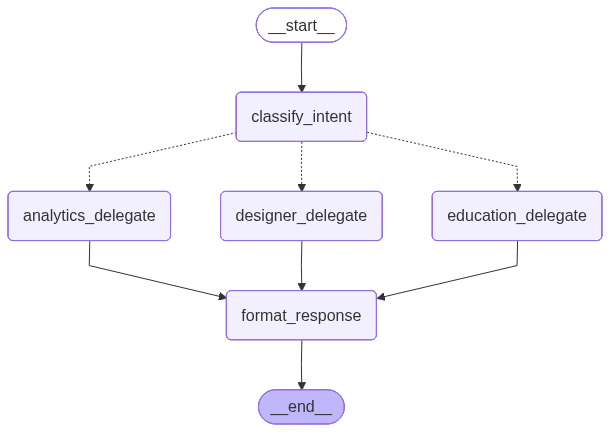

In [24]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("(Graph visualisation requires extra dependencies -- skipping)")

## Demo: Analytics Query

Test the orchestrator with an analytics query. This will:
1. Classify the intent as "analytics"
2. Run the full NB12 pipeline (live data, scoring, LLM analysis)

**Note**: This fetches live market data, so it may take 15-30 seconds.

In [ ]:
print("=" * 70)
print("DEMO: Analytics Query")
print("=" * 70)

result = graph.invoke(
    OrchestratorState(
        messages=[HumanMessage(content="Analyze my portfolio and tell me which holdings to rebalance")]
    )
)

print(f"\nRouted to: {result['intent']}")
display(Markdown(result["messages"][-1].content))

DEMO: Analytics Query
  [Node 1] Classifying intent...
Loading LLM: openai / gpt-4.1-mini
    Intent: analytics
    Reason: User requests portfolio analysis and rebalancing recommendations
  [Node 2a] Analytics Delegate
    Portfolio: 'Sample Balanced Growth Portfolio' with 9 holdings
    Building benchmark context...


## Demo: Education Query

Test the orchestrator with an education query.

In [ ]:
print("=" * 70)
print("DEMO: Education Query")
print("=" * 70)

result = graph.invoke(
    OrchestratorState(
        messages=[HumanMessage(content="What is the difference between growth and value investing?")]
    )
)

print(f"\nRouted to: {result['intent']}")
display(Markdown(result["messages"][-1].content))

DEMO: Education Query
  [Node 1] Classifying intent...
Loading LLM: openai / gpt-4.1-mini
    Intent: education
    Reason: User wants to learn about the difference between growth and value investing, which is an investment concept explanation.
  [Node 2b] Education Delegate
Loading LLM: openai / gpt-4.1-mini
    Education delegate complete
  [Node 3] Format response (handled by: education)

Routed to: education


Great question! Understanding the difference between growth and value investing is fundamental to building an investment strategy.

**Growth Investing** focuses on companies expected to grow their earnings or revenues faster than the overall market. These companies often reinvest profits to expand, innovate, or capture market share rather than paying high dividends. Growth stocks tend to have higher price-to-earnings (P/E) ratios because investors are willing to pay a premium for future growth potential. Examples include many tech companies or emerging industries.

**Value Investing** looks for companies that appear undervalued compared to their fundamentals, such as earnings, book value, or dividends. Value investors seek stocks trading at a discount, often with lower P/E or price-to-book (P/B) ratios, expecting the market to eventually recognize their true worth. These companies might be more established, with stable cash flows and sometimes higher dividend yields.

**Real-world example:**
- Apple (AAPL) in your portfolio is often considered a growth stock because of its innovation and strong earnings growth.
- Johnson & Johnson (JNJ) is more of a value stock, known for steady dividends and stable earnings in healthcare.

**Why it matters:**
- Growth stocks can offer higher returns but often come with higher volatility.
- Value stocks may provide more stability and income but might grow more slowly.

Your portfolio has a mix of both: AAPL (growth), JNJ (value), and broad ETFs like VTI and QQQ that lean growth-heavy (QQQ especially focuses on tech growth stocks). This blend can help balance growth potential with stability.

Would you like me to explain how to analyze growth vs. value stocks using financial metrics or how to balance them in your portfolio? Just let me know!

*Note: This explanation is for educational purposes and not financial advice.*

## Demo: Designer Query

Test the orchestrator with a portfolio design query. This will:
1. Classify the intent as "designer"
2. Route to the NB11 profiling agent (may ask follow-up profiling questions)

In [ ]:
print("=" * 70)
print("DEMO: Designer Query")
print("=" * 70)

result = graph.invoke(
    OrchestratorState(
        messages=[HumanMessage(content="I am 45, moderate risk, retiring in 15 years -- build me a portfolio")]
    )
)

print(f"\nRouted to: {result['intent']}")
display(Markdown(result["messages"][-1].content))

DEMO: Designer Query
  [Node 1] Classifying intent...
Loading LLM: openai / gpt-4.1-mini
    Intent: designer
    Reason: User wants to build a portfolio with moderate risk and a 15-year retirement timeline.
  [Node 2c] Designer Delegate
    Designer delegate complete
  [Node 3] Format response (handled by: designer)

Routed to: designer


Great! Thanks for sharing that you are 45 years old, have a moderate risk tolerance, and plan to retire in 15 years. To tailor the portfolio better, could you please tell me:

1. What are your primary investment goals? (e.g., growth, income, capital preservation)
2. Do you prefer investing in ETFs, individual stocks, or a mix of both?
3. Are there any sectors you want to emphasize or avoid?

This will help me design a portfolio that fits your preferences and goals.

## Multi-Turn Orchestrator Chat

The `OrchestratorChat` wrapper maintains conversation history across turns.
Each message is re-classified, so you can alternate between analytics
and education questions freely.

In [ ]:
class OrchestratorChat:
    """Multi-turn chat wrapper with automatic intent routing.

    Each message is classified independently, so the user can
    switch between analytics and education queries mid-conversation.
    """

    def __init__(self, graph):
        self.graph = graph
        self.conversation_history: list[BaseMessage] = []

    def ask(self, question: str) -> str:
        """Send a question, route to the appropriate agent, return response."""
        self.conversation_history.append(HumanMessage(content=question))

        result = self.graph.invoke(
            OrchestratorState(messages=self.conversation_history)
        )

        ai_message = result["messages"][-1]
        self.conversation_history.append(ai_message)

        intent = result.get("intent", "unknown")
        print(f"  [Routed to: {intent}]")

        return ai_message.content

    def reset(self):
        """Clear conversation history."""
        self.conversation_history = []
        print("Conversation history cleared")

    def show_history(self):
        """Display conversation history."""
        print("=" * 70)
        print("CONVERSATION HISTORY")
        print("=" * 70)
        for i, msg in enumerate(self.conversation_history):
            role = "USER" if isinstance(msg, HumanMessage) else "AI"
            print(f"\n[{i + 1}] {role}:")
            print(msg.content[:200] + ("..." if len(msg.content) > 200 else ""))
        print("=" * 70)


chat = OrchestratorChat(graph)

print("OrchestratorChat ready")
print("  Usage: response = chat.ask('your question here')")
print("  Reset: chat.reset()")
print("  History: chat.show_history()")

OrchestratorChat ready
  Usage: response = chat.ask('your question here')
  Reset: chat.reset()
  History: chat.show_history()


## Try a Multi-Turn Conversation

The orchestrator routes each question independently. Watch how it
switches between agents based on what you ask.

In [ ]:
response = chat.ask("What is portfolio diversification and why does it matter?")
display(Markdown(response))

  [Node 1] Classifying intent...
Loading LLM: openai / gpt-4.1-mini
    Intent: education
    Reason: User wants to learn about the concept of portfolio diversification and its importance.
  [Node 2b] Education Delegate
Loading LLM: openai / gpt-4.1-mini
    Education delegate complete
  [Node 3] Format response (handled by: education)
  [Routed to: education]


Great question! Portfolio diversification is the practice of spreading your investments across different assets, sectors, or geographic regions to reduce risk. The idea is that by not putting all your eggs in one basket, you can protect your portfolio from big losses if one investment or sector performs poorly.

Why does diversification matter? Because different assets often react differently to the same economic events. For example, when the stock market drops, bonds or gold might hold their value or even go up, helping to cushion your overall portfolio.

Looking at your portfolio, you have a good mix of asset types:
- Stocks through broad ETFs like VTI (total U.S. stock market) and QQQ (tech-heavy Nasdaq)
- Sector ETFs like XLV (healthcare), XLE (energy)
- International exposure with VWO (emerging markets)
- Bonds with BND
- Gold with GLD

This mix helps reduce risk because:
- Bonds (BND) tend to be less volatile than stocks and often move differently than stocks.
- Gold (GLD) can act as a hedge against inflation or market turmoil.
- Emerging markets (VWO) add geographic diversification but can be more volatile.
- Sector ETFs and individual stocks like AAPL and JNJ give you targeted exposure but also add some concentration risk.

One thing to note is your portfolio is underweight in several sectors compared to the S&P 500, like financials, consumer cyclical, and communication services. This means you might be missing out on diversification benefits those sectors provide.

In summary, diversification helps smooth out returns and reduce the chance of big losses. It’s a key principle in managing investment risk.

Feel free to ask if you want to dive deeper into how to diversify better or how your current holdings contribute to your portfolio’s risk and return! Just a reminder, this is for educational purposes and not financial advice.

In [ ]:
response = chat.ask("Run a full analysis on my portfolio with risk metrics")
display(Markdown(response))

  [Node 1] Classifying intent...
Loading LLM: openai / gpt-4.1-mini
    Intent: analytics
    Reason: User requests a full analysis on their portfolio including risk metrics.
  [Node 2a] Analytics Delegate
    Portfolio: 'Sample Balanced Growth Portfolio' with 9 holdings
    Building benchmark context...


Exception ignored from cffi callback <function buffer_callback at 0x111ff84a0>:
Traceback (most recent call last):
  File "/opt/homebrew/lib/python3.11/site-packages/curl_cffi/curl.py", line 100, in buffer_callback
    @ffi.def_extern()
    
KeyboardInterrupt: 


    yfinance info failed for XLE: Failed to perform, curl: (23) Failure writing output to destination, passed 13 returned 0. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
    Analyzing holdings (live data + 17-rule scoring)...
      -> VTI (25.0%)... Score: 5 [HOLD]
      -> QQQ (15.0%)... Score: 4 [HOLD]
      -> XLV (10.0%)... Score: 7 [HOLD]
      -> VWO (10.0%)... Score: 8 [HOLD]
      -> XLE (5.0%)... Score: 10 [BUY]
      -> AAPL (10.0%)... Score: 5 [HOLD]
      -> JNJ (5.0%)... Score: 7 [HOLD]
      -> BND (15.0%)... Score: 4 [HOLD]
      -> GLD (5.0%)... Score: 4 [HOLD]
    Computing risk metrics...
      Beta: 0.854, Risk: LOW
    Generating LLM analysis...
Loading LLM: openai / gpt-4.1-mini


In [ ]:
response = chat.ask("You mentioned RSI in the analysis. Can you explain what RSI means and how to interpret it?")
display(Markdown(response))

In [ ]:
response = chat.ask("Based on what you told me about diversification, is my portfolio well diversified?")
display(Markdown(response))

## View Conversation History

In [ ]:
chat.show_history()

## Demo: Cross-Agent Routing Queries

Each demo sends a query through the orchestrator. Watch the `[Routed to:]`
tag to see which agent handles each question. The conversation history
is maintained across demos so the agent can reference earlier exchanges.

In [ ]:
chat.reset()

# Demo 1: Portfolio health (Analytics)
print("=" * 70)
print("Demo 1: Portfolio Health")
print("=" * 70)
print("\nUser: How is my portfolio doing this month?")
response = chat.ask("How is my portfolio doing this month?")
print(f"\nBot: {response}")

In [ ]:
# Demo 2: Sharpe ratio explanation (Education)
print("=" * 70)
print("Demo 2: Sharpe Ratio Explanation")
print("=" * 70)
print("\nUser: Actually, before that — explain what Sharpe ratio means.")
response = chat.ask("Actually, before that — explain what Sharpe ratio means.")
print(f"\nBot: {response}")

In [ ]:
# Demo 3: Rebalancing (Analytics)
print("=" * 70)
print("Demo 3: Should I Rebalance?")
print("=" * 70)
print("\nUser: Now, based on that explanation, should I rebalance?")
response = chat.ask("Now, based on that explanation, should I rebalance?")
print(f"\nBot: {response}")

In [ ]:
# Demo 4: Healthcare ETFs only (Analytics)
print("=" * 70)
print("Demo 4: Healthcare ETF Analysis")
print("=" * 70)
print("\nUser: Only analyze my healthcare ETFs.")
response = chat.ask("Only analyze my healthcare ETFs.")
print(f"\nBot: {response}")

In [ ]:
# Demo 5: VTI comparison (Analytics)
print("=" * 70)
print("Demo 5: VTI vs Total Portfolio")
print("=" * 70)
print("\nUser: How is VTI performing compared to my total portfolio?")
response = chat.ask("How is VTI performing compared to my total portfolio?")
print(f"\nBot: {response}")

In [ ]:
# Demo 6: Volatility contributor (Analytics)
print("=" * 70)
print("Demo 6: Volatility Contributor")
print("=" * 70)
print("\nUser: Which holding contributes most to my volatility?")
response = chat.ask("Which holding contributes most to my volatility?")
print(f"\nBot: {response}")

In [ ]:
# Demo 7: Remove NVDA scenario (Analytics)
print("=" * 70)
print("Demo 7: What If I Remove NVDA?")
print("=" * 70)
print("\nUser: What happens if I remove NVDA?")
response = chat.ask("What happens if I remove NVDA?")
print(f"\nBot: {response}")

In [ ]:
# Demo 8: Increase bonds (Designer)
print("=" * 70)
print("Demo 8: What If I Increase Bonds?")
print("=" * 70)
print("\nUser: What if I increase bonds to 30%?")
response = chat.ask("What if I increase bonds to 30%?")
print(f"\nBot: {response}")

In [ ]:
# Demo 9: Interest rate impact (Education)
print("=" * 70)
print("Demo 9: Interest Rate Impact")
print("=" * 70)
print("\nUser: What happens if interest rates rise?")
response = chat.ask("What happens if interest rates rise?")
print(f"\nBot: {response}")

In [ ]:
# Demo 10: Recession simulation (Analytics)
print("=" * 70)
print("Demo 10: Recession Scenario")
print("=" * 70)
print("\nUser: Simulate a recession scenario.")
response = chat.ask("Simulate a recession scenario.")
print(f"\nBot: {response}")

In [ ]:
# Demo 11: 2008-type crash (Analytics)
print("=" * 70)
print("Demo 11: 2008-Type Crash Scenario")
print("=" * 70)
print("\nUser: How would my portfolio behave in a 2008-type crash?")
response = chat.ask("How would my portfolio behave in a 2008-type crash?")
print(f"\nBot: {response}")

In [ ]:
# Demo 12: Retirement planning (Designer)
print("=" * 70)
print("Demo 12: Retirement Planning")
print("=" * 70)
print("\nUser: I want to retire at 60. Am I on track?")
response = chat.ask("I want to retire at 60. Am I on track?")
print(f"\nBot: {response}")

In [ ]:
# Demo 13: Reduce risk (Analytics)
print("=" * 70)
print("Demo 13: Reduce Risk, Maintain Returns")
print("=" * 70)
print("\nUser: Can I reduce risk but maintain returns?")
response = chat.ask("Can I reduce risk but maintain returns?")
print(f"\nBot: {response}")

In [ ]:
# Demo 14: Healthcare exposure (Education)
print("=" * 70)
print("Demo 14: Healthcare Exposure Limits")
print("=" * 70)
print("\nUser: How much healthcare exposure is too much?")
response = chat.ask("How much healthcare exposure is too much?")
print(f"\nBot: {response}")

In [ ]:
# Demo 15: Beta explanation (Education)
print("=" * 70)
print("Demo 15: Beta in Context")
print("=" * 70)
print("\nUser: Explain beta in the context of my portfolio.")
response = chat.ask("Explain beta in the context of my portfolio.")
print(f"\nBot: {response}")

In [ ]:
# Demo 16: Portfolio volatility vs S&P (Analytics)
print("=" * 70)
print("Demo 16: Portfolio Volatility vs S&P")
print("=" * 70)
print("\nUser: Why is my portfolio more volatile than the S&P?")
response = chat.ask("Why is my portfolio more volatile than the S&P?")
print(f"\nBot: {response}")

In [ ]:
# Demo 17: Diversification with holdings (Education)
print("=" * 70)
print("Demo 17: Diversification Using Your Holdings")
print("=" * 70)
print("\nUser: Teach me how diversification reduces risk using my holdings.")
response = chat.ask("Teach me how diversification reduces risk using my holdings.")
print(f"\nBot: {response}")

## Interactive Chat Loop

Free-form interactive chat with automatic routing.
Type `quit` or `exit` to stop.

In [ ]:
chat.reset()

print("=" * 70)
print("ORCHESTRATOR AGENT - INTERACTIVE CHAT")
print("=" * 70)
if PORTFOLIO:
    tickers = [h['ticker'] for h in PORTFOLIO['holdings']]
    print(f"Portfolio loaded: {', '.join(tickers)}")
else:
    print("No portfolio loaded")
print("Queries are automatically routed to Designer, Analytics, or Education agents.")
print("Type 'quit' or 'exit' to stop.")
print("=" * 70)

while True:
    user_input = input("\nYou: ").strip()
    if not user_input:
        continue
    if user_input.lower() in ("quit", "exit", "q"):
        print("\nChat ended. Use chat.show_history() to review.")
        break

    response = chat.ask(user_input)
    print(f"\nAI: {response}")

## Example Questions to Try

**Will route to Designer Agent:**
- "Help me build a long-term growth portfolio"
- "I am 30, aggressive risk, 20-year horizon — design a portfolio"
- "What if I increase bonds to 30%?"
- "I want to retire at 60. Am I on track?"

**Will route to Analytics Agent:**
- "Analyze my portfolio risk"
- "Which of my holdings should I sell?"
- "Show me the sector breakdown vs S&P 500"
- "Run the full scoring pipeline on my portfolio"

**Will route to Education Agent:**
- "What is a golden cross?"
- "Explain the difference between P/E and P/B ratios"
- "How does sector rotation work?"
- "What should I learn about before investing in ETFs?"

**Interesting routing tests:**
- "Why is my portfolio risky?" (could go either way)
- "Teach me about the metrics you used in the analysis" (education follow-up)
- "Can I reduce risk but maintain returns?" (analytics vs designer)

In [ ]:
# Try your own question:
# response = chat.ask("Your question here")
# display(Markdown(response))

## Summary

- **Orchestrator Agent** with tool-based intent classification
- **Conditional routing**: LangGraph `add_conditional_edges` for non-linear flow
- **Three delegates**: Designer (NB11), Analytics (NB12), Education (NB13)
- **Designer delegate**: Inner tool-calling agent loop with MemorySaver for multi-turn profiling
- **Analytics delegate**: Full NB12 pipeline (live data, 17 rules, structured signals)
- **Education delegate**: Full NB13 pipeline (context enrichment, multi-turn)
- **Multi-turn conversation**: Automatic re-classification per turn

### Architecture
```
         classify_intent
              |
    +---------+---------+
    |         |         |
designer  analytics  education
_delegate _delegate  _delegate
    |         |         |
    +---------+---------+
              |
       format_response -> END
```

### Four-Agent System
```
Notebook 11 (Designer)    -> portfolio.json -> Notebook 12 (Analytics)
  (profiling chatbot)     -> portfolio.json -> Notebook 13 (Education)
                          -> portfolio.json -> Notebook 14 (Orchestrator)
                                                  |
                                           Routes to 11, 12, or 13
```

### Key Differences from Other Notebooks
| Feature | NB 11 (Designer) | NB 12 (Analytics) | NB 13 (Education) | NB 14 (This) |
|---------|-----------------|------------------|--------------------|---------------|
| Graph shape | Agent loop | Linear (5 nodes) | Linear (2 nodes) | Conditional routing |
| Nodes | 2 + ToolNode | 5 | 2 | 5 (with 3-way branching) |
| Tools | search_web, portfolio_generation | None | None | Handoff tools (routing) + designer tools |
| Routing | Tool loop | None | None | Tool-based LLM classification |
| Sub-agents | N/A | N/A | N/A | Designer + Analytics + Education |
| LLM calls | Multiple per conversation | 1-2 | 1 per turn | 1 (classify) + delegate LLM calls |
| Conversation | Multi-turn profiling | One-shot | Multi-turn | Multi-turn with routing |
| Conditional edges | Yes (tool loop) | No | No | Yes (`add_conditional_edges`) |